In [410]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from scipy import stats

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import random


### MARKET + ONCHAIN DATA

In [411]:
bitcoin_df = pd.read_csv('bitcoin-price.csv')
market_df = pd.read_csv('market-data.csv')
onchain_df = pd.read_csv('on-chain-data.csv')

bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Datetime']).dt.date
market_df['Date'] = pd.to_datetime(market_df['Dates']).dt.date
onchain_df['Date'] = pd.to_datetime(onchain_df['Datetime']).dt.date

bitcoin_close = bitcoin_df[['Date', 'Close']].copy()
print(f"Bitcoin date range: {bitcoin_close['Date'].min()} to {bitcoin_close['Date'].max()}")
print(f"Market date range: {market_df['Date'].min()} to {market_df['Date'].max()}")
print(f"On-chain date range: {onchain_df['Date'].min()} to {onchain_df['Date'].max()}")

Bitcoin date range: 2009-01-03 to 2025-06-10
Market date range: 2017-01-02 to 2025-06-23
On-chain date range: 2019-03-30 to 2025-06-09


In [412]:
market_df_clean = market_df.drop(columns=['Dates'])
bitcoin_market_df = pd.merge(bitcoin_close, market_df_clean, on='Date', how='inner')
bitcoin_market_df = bitcoin_market_df.dropna()
bitcoin_market_df = bitcoin_market_df.rename(columns={'Close': 'Bitcoin Close'})

print(f"Shape: {bitcoin_market_df.shape}")
print(f"Date range: {bitcoin_market_df['Date'].min()} to {bitcoin_market_df['Date'].max()}")
print(f"Columns: {list(bitcoin_market_df.columns)}")
bitcoin_market_df.head()

Shape: (2202, 13)
Date range: 2017-01-02 to 2025-06-10
Columns: ['Date', 'Bitcoin Close', 'SPX Index', 'CCMP Index', 'INDU Index', 'XAU Curncy', 'CL1 Comdty', 'XAG Curncy', 'LMCADY Comdty', 'NG1 Comdty', 'DXY Curncy', 'EURUSD Curncy', 'USDCNY Curncy']


,Date,Bitcoin Close,SPX Index,CCMP Index,INDU Index,XAU Curncy,CL1 Comdty,XAG Curncy,LMCADY Comdty,NG1 Comdty,DXY Curncy,EURUSD Curncy,USDCNY Curncy
0,2025-06-10,108923.014410,6038.81,19714.99,42866.87,3323.69,64.98,36.5350,9840.60,3.533,99.098,1.1425,7.1878
1,2025-06-09,110303.871227,6005.88,19591.24,42761.76,3326.19,65.29,36.7584,9888.78,3.635,98.939,1.1422,7.1794
2,2025-06-06,104406.924809,6000.36,19529.95,42762.87,3310.42,64.58,35.9777,9762.84,3.784,99.190,1.1397,7.1926
3,2025-06-05,101613.260806,5939.30,19298.45,42319.74,3352.65,63.37,35.6510,9832.65,3.677,98.741,1.1445,7.1777
4,2025-06-04,104724.591994,5970.81,19460.49,42427.74,3372.72,62.85,34.5045,9669.98,3.716,98.787,1.1417,7.1780


In [413]:
onchain_df_clean = onchain_df.drop(columns=['Datetime'])
bitcoin_onchain_df = pd.merge(bitcoin_close, onchain_df_clean, on='Date', how='inner')
bitcoin_onchain_df = bitcoin_onchain_df.dropna()
bitcoin_onchain_df = bitcoin_onchain_df.rename(columns={'Close': 'Bitcoin Close'})

print(f"Shape: {bitcoin_onchain_df.shape}")
print(f"Date range: {bitcoin_onchain_df['Date'].min()} to {bitcoin_onchain_df['Date'].max()}")
print(f"Columns: {list(bitcoin_onchain_df.columns)}")
bitcoin_onchain_df.head()

Shape: (2264, 14)
Date range: 2019-03-30 to 2025-06-09
Columns: ['Date', 'Bitcoin Close', 'Active Addresses', 'Exchange Reserve', 'Exchange Netflow', 'Fee-Reward Ratio', 'Funding Rates', 'Hashrate', 'Mean Coin Age', 'Miner Reserve', 'MVRV Ratio', 'Open Interest', 'Puell Multiple', 'SOPR']


,Date,Bitcoin Close,Active Addresses,Exchange Reserve,Exchange Netflow,Fee-Reward Ratio,Funding Rates,Hashrate,Mean Coin Age,Miner Reserve,MVRV Ratio,Open Interest,Puell Multiple,SOPR
0,2025-06-09,110303.871227,893460.0,2.502490e+06,-3127.633553,0.011309,0.002927,8.837253e+11,1617.120227,1.808101e+06,2.340974,3.784251e+10,1.243001,1.013669
1,2025-06-08,105782.295477,779831.0,2.505618e+06,370.863428,0.006581,0.002124,9.657855e+11,1616.485453,1.807721e+06,2.247120,3.604954e+10,1.337595,1.011710
2,2025-06-07,105645.525274,787698.0,2.505247e+06,-1925.698528,0.007294,-0.000949,9.026623e+11,1615.764529,1.807631e+06,2.245429,3.601397e+10,1.245541,1.013583
3,2025-06-06,104406.924809,859500.0,2.507173e+06,-6228.992664,0.010475,-0.004703,8.458514e+11,1615.110946,1.807638e+06,2.220515,3.543465e+10,1.152875,1.006889
4,2025-06-05,101613.260806,866463.0,2.513402e+06,450.194966,0.011510,0.001402,8.458514e+11,1614.501350,1.807730e+06,2.162189,3.385101e+10,1.156797,1.002772


In [414]:
# calculate correlation matrices
market_numeric_cols = [col for col in bitcoin_market_df.columns if col != 'Date']
market_numeric_data = bitcoin_market_df[market_numeric_cols].select_dtypes(include=[np.number])
market_correlation_matrix = market_numeric_data.corr()

onchain_numeric_cols = [col for col in bitcoin_onchain_df.columns if col != 'Date']
onchain_numeric_data = bitcoin_onchain_df[onchain_numeric_cols].select_dtypes(include=[np.number])
onchain_correlation_matrix = onchain_numeric_data.corr()

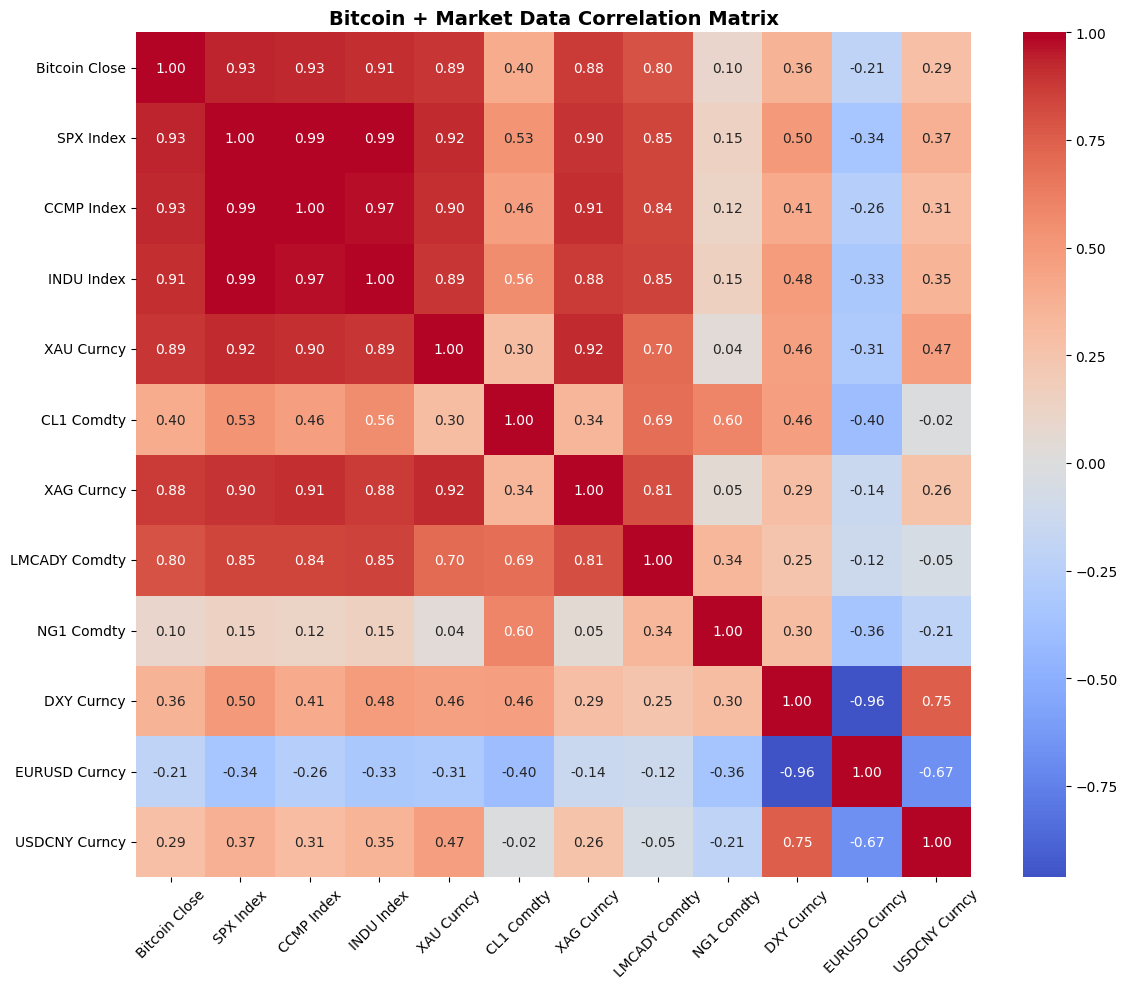

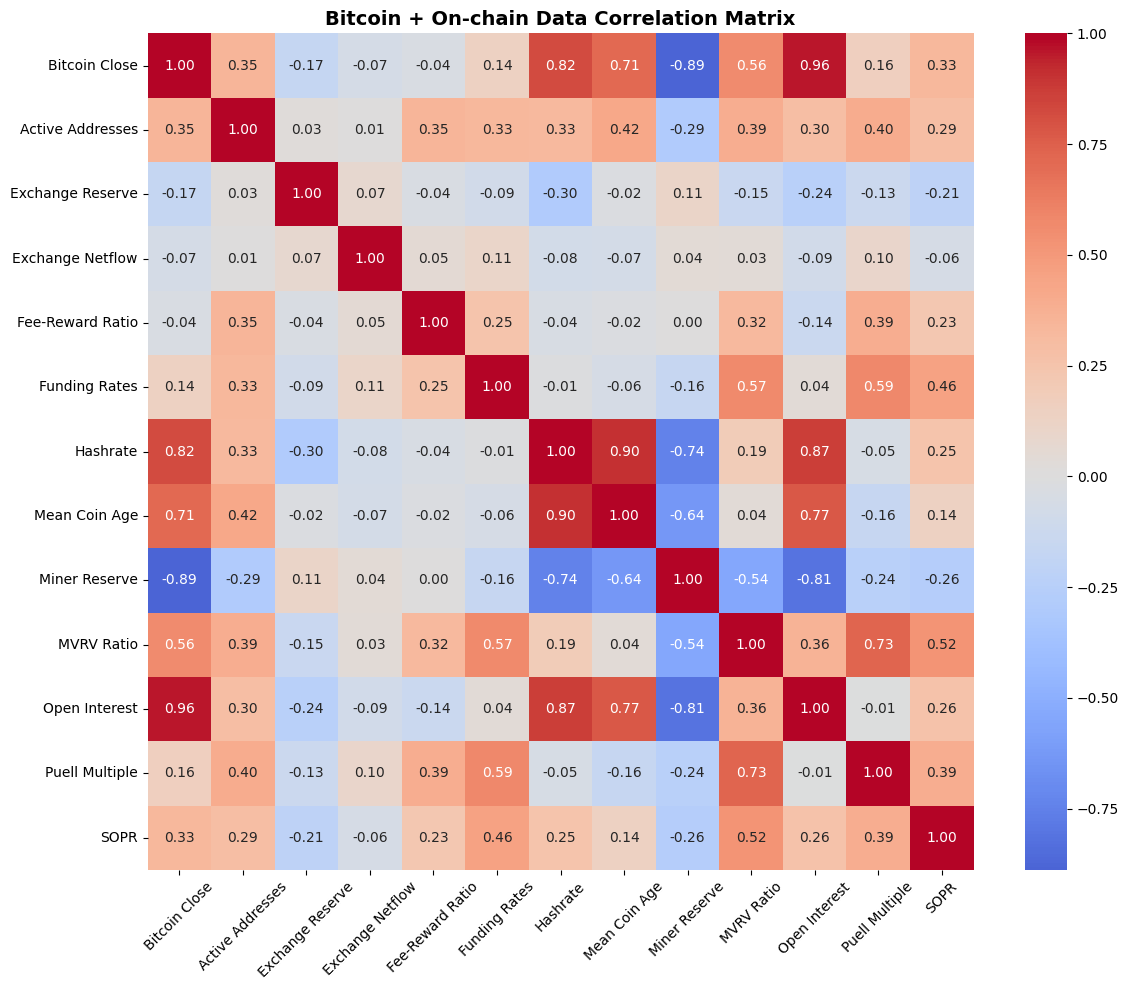

In [415]:
# market data correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(market_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Bitcoin + Market Data Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# on-chain correlation heatamp 
plt.figure(figsize=(12, 10))
sns.heatmap(onchain_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Bitcoin + On-chain Data Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### LINEAR INTERPOLATION ON ECONOMIC INDICATORS

In [416]:
# prep for linear interpolation
economic_monthly = pd.read_csv('economic-monthly.csv')
economic_monthly['Date'] = pd.to_datetime(economic_monthly['Dates'])
economic_monthly = economic_monthly.drop(columns=['Dates']).sort_values('Date')

start_date = economic_monthly['Date'].min()
end_date = economic_monthly['Date'].max()
daily_dates = pd.date_range(start=start_date, end=end_date, freq='D') # daily frequency

print(f"Original monthly data points: {len(economic_monthly)}")
print(f"New daily data points: {len(daily_dates)}")

economic_monthly = economic_monthly.set_index('Date')


Original monthly data points: 90
New daily data points: 2709


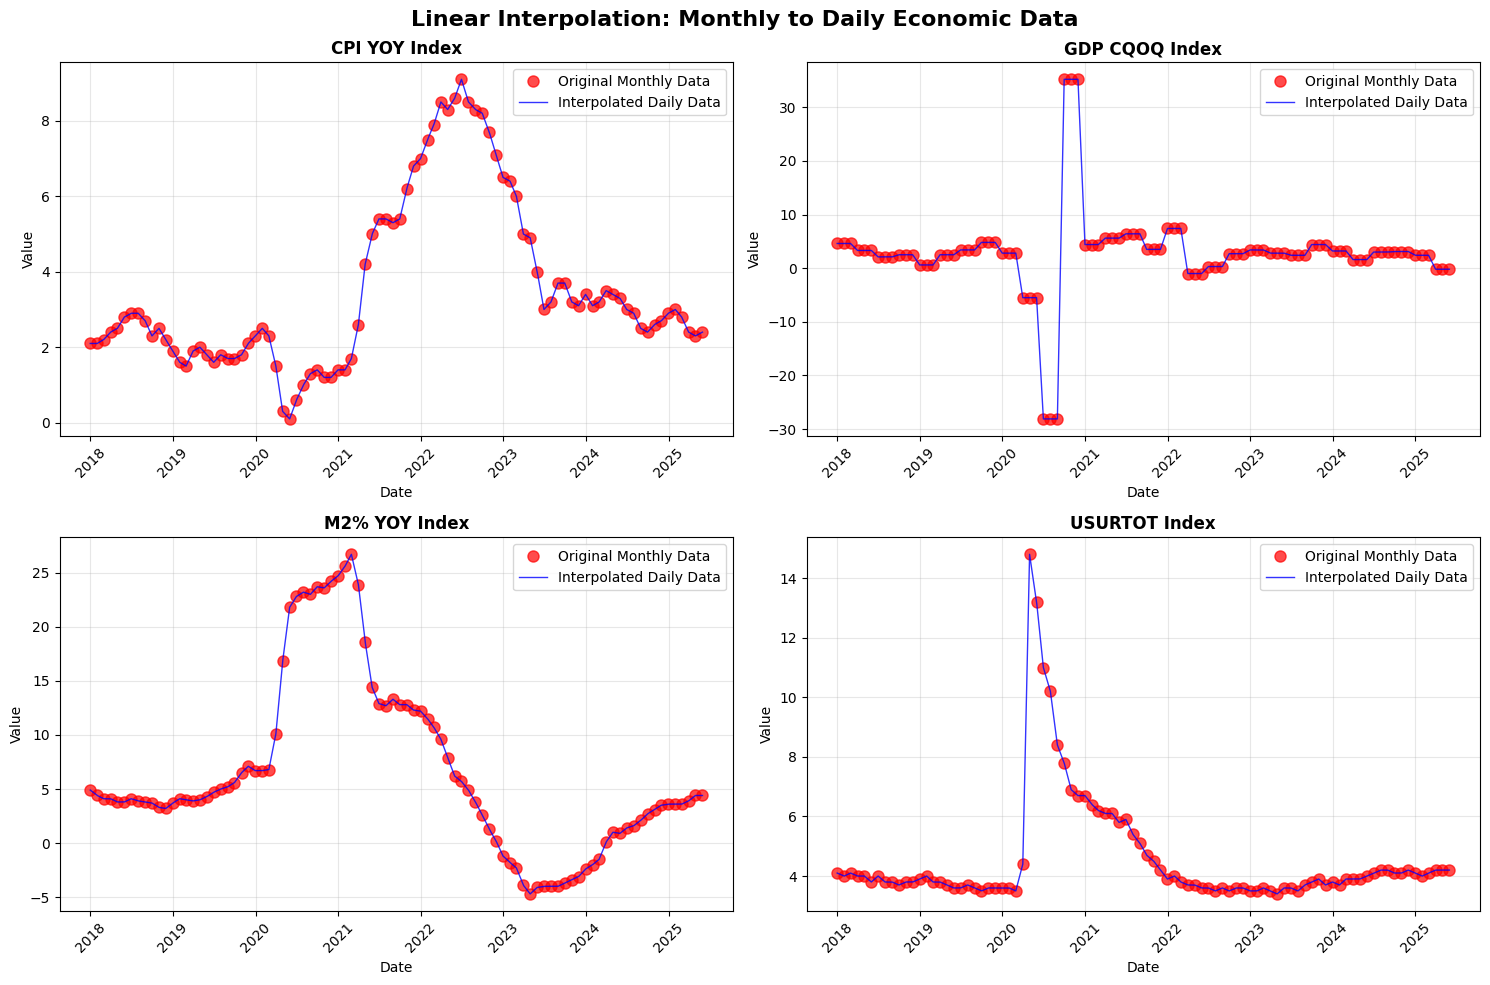

,Date,CPI YOY Index,GDP CQOQ Index,M2% YOY Index,USURTOT Index
0,2025-05-31,2.400000,-0.2,4.4,4.2
1,2025-05-30,2.396774,-0.2,4.4,4.2
2,2025-05-29,2.393548,-0.2,4.4,4.2
3,2025-05-28,2.390323,-0.2,4.4,4.2
4,2025-05-27,2.387097,-0.2,4.4,4.2


In [417]:
# perform linear interpolation to create daily values
economic_daily = economic_monthly.reindex(daily_dates)
economic_daily = economic_daily.interpolate(method='linear')

economic_daily = economic_daily.reset_index()
economic_daily = economic_daily.rename(columns={'index': 'Date'})

# show interpolation results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# interpolation for each economic indicator
economic_indicators = ['CPI YOY Index', 'GDP CQOQ Index', 'M2% YOY Index', 'USURTOT Index']

for i, indicator in enumerate(economic_indicators):
    # original monthly data points
    axes[i].plot(economic_monthly.index, economic_monthly[indicator], 
                'ro', markersize=8, label='Original Monthly Data', alpha=0.7)
    
    # interpolated daily data
    axes[i].plot(economic_daily['Date'], economic_daily[indicator], 
                'b-', linewidth=1, label='Interpolated Daily Data', alpha=0.8)
    
    axes[i].set_title(f'{indicator}', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Linear Interpolation: Monthly to Daily Economic Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

economic_daily['Date'] = economic_daily['Date'].dt.date
economic_daily = economic_daily.sort_values('Date', ascending=False).reset_index(drop=True)
economic_daily.head()

In [418]:
economic_daily = economic_daily.reset_index(drop=True)
economic_daily_df = pd.read_csv('economic-daily.csv')
economic_more_df = pd.read_csv('economic-more.csv')

economic_daily_df['Date'] = pd.to_datetime(economic_daily_df['Date']).dt.date
economic_more_df['Date'] = pd.to_datetime(economic_more_df.iloc[:, 0]).dt.date

economic_more_clean = economic_more_df.drop(columns=[economic_more_df.columns[0]])
economic_more_clean['Date'] = economic_more_df['Date']

bitcoin_economic_df = bitcoin_close.copy()
bitcoin_economic_df = pd.merge(bitcoin_economic_df, economic_daily_df, on='Date', how='inner')
bitcoin_economic_df = pd.merge(bitcoin_economic_df, economic_more_clean, on='Date', how='inner')
bitcoin_economic_df = bitcoin_economic_df.dropna()
bitcoin_economic_df = bitcoin_economic_df.rename(columns={'Close': 'Bitcoin Close'})

print(f"Final shape: {bitcoin_economic_df.shape}")
print(f"Date range: {bitcoin_economic_df['Date'].min()} to {bitcoin_economic_df['Date'].max()}")
print(f"Total features: {bitcoin_economic_df.shape[1] - 1} (excluding Date)")
print(f"\nColumns: {list(bitcoin_economic_df.columns)}")

bitcoin_economic_df.head()

Final shape: (1935, 8)
Date range: 2018-01-01 to 2025-05-30
Total features: 7 (excluding Date)

Columns: ['Date', 'Bitcoin Close', 'CPI YOY Index', 'GDP CQOQ Index', 'M2% YOY Index', 'USURTOT Index', 'FDTR Index', 'USGG10YR Index']


,Date,Bitcoin Close,CPI YOY Index,GDP CQOQ Index,M2% YOY Index,USURTOT Index,FDTR Index,USGG10YR Index
0,2025-05-30,104021.226785,2.396774,-0.2,4.4,4.2,4.5,4.4004
1,2025-05-29,105521.117278,2.393548,-0.2,4.4,4.2,4.5,4.4180
2,2025-05-28,107800.867686,2.390323,-0.2,4.4,4.2,4.5,4.4773
3,2025-05-27,108918.897182,2.387097,-0.2,4.4,4.2,4.5,4.4436
4,2025-05-26,109460.004815,2.383871,-0.2,4.4,4.2,4.5,4.5110


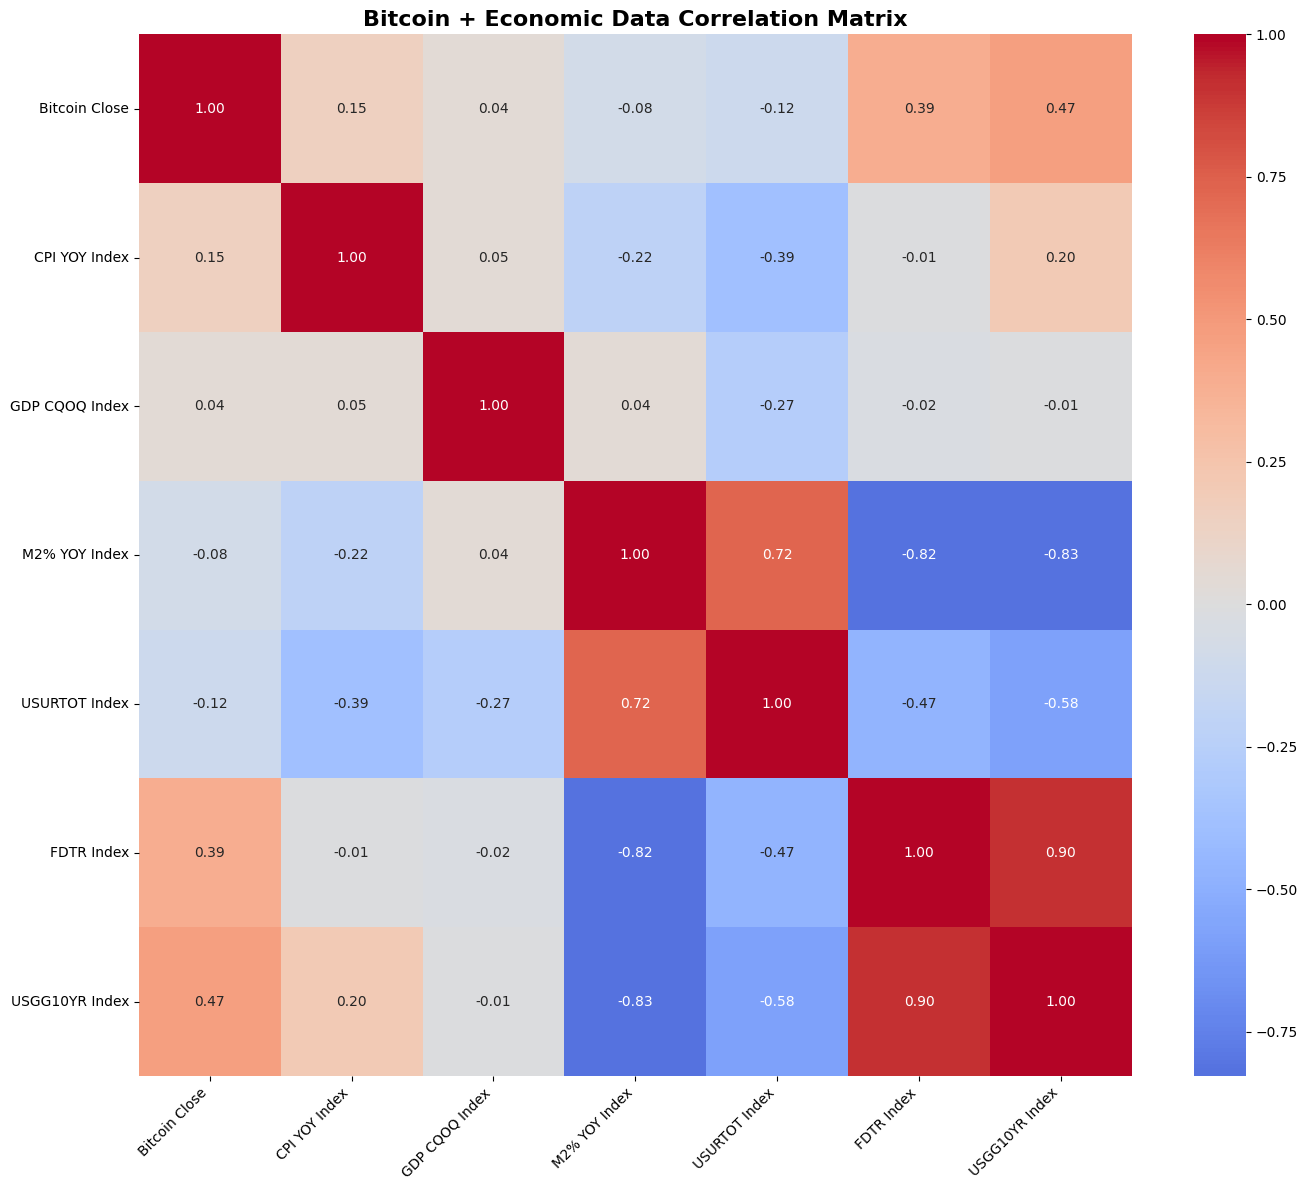

In [419]:
economic_numeric_cols = [col for col in bitcoin_economic_df.columns if col != 'Date']
economic_numeric_data = bitcoin_economic_df[economic_numeric_cols].select_dtypes(include=[np.number])

economic_bitcoin_correlation_matrix = economic_numeric_data.corr()
close_correlations_economic = economic_bitcoin_correlation_matrix['Bitcoin Close'].sort_values(ascending=False)

# visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(economic_bitcoin_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Bitcoin + Economic Data Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### COMBINATION OF DATA FOR FEATURE SELECTION

In [420]:
df = bitcoin_market_df.copy()

onchain_features = [col for col in bitcoin_onchain_df.columns if col not in ['Date', 'Close', 'Bitcoin Close']]
onchain_for_merge = bitcoin_onchain_df[['Date'] + onchain_features]
df = pd.merge(df, onchain_for_merge, on='Date', how='inner')

economic_features = [col for col in bitcoin_economic_df.columns if col not in ['Date', 'Close', 'Bitcoin Close']]
economic_for_merge = bitcoin_economic_df[['Date'] + economic_features]
df = pd.merge(df, economic_for_merge, on='Date', how='inner')

df = df.dropna()
print(df.shape)
df.head()

(1610, 31)


,Date,Bitcoin Close,SPX Index,CCMP Index,INDU Index,XAU Curncy,CL1 Comdty,XAG Curncy,LMCADY Comdty,NG1 Comdty,...,MVRV Ratio,Open Interest,Puell Multiple,SOPR,CPI YOY Index,GDP CQOQ Index,M2% YOY Index,USURTOT Index,FDTR Index,USGG10YR Index
0,2025-05-30,104021.226785,5911.69,19113.77,42270.07,3289.25,60.79,32.9832,9548.08,3.447,...,2.229398,3.547970e+10,1.364412,1.011402,2.396774,-0.2,4.4,4.2,4.5,4.4004
1,2025-05-29,105521.117278,5912.17,19175.87,42215.73,3317.94,60.94,33.3192,9619.57,3.522,...,2.263659,3.700044e+10,1.419713,1.025977,2.393548,-0.2,4.4,4.2,4.5,4.4180
2,2025-05-28,107800.867686,5888.55,19100.94,42098.70,3287.48,61.84,32.9840,9609.97,3.204,...,2.316694,3.711202e+10,1.494099,1.016935,2.390323,-0.2,4.4,4.2,4.5,4.4773
3,2025-05-27,108918.897182,5921.54,19199.16,42343.65,3300.87,60.89,33.2645,9636.58,3.398,...,2.344105,3.676131e+10,1.297240,1.041139,2.387097,-0.2,4.4,4.2,4.5,4.4436
4,2025-05-26,109460.004815,5802.82,18737.21,41603.07,3343.84,61.53,33.4906,9641.14,3.334,...,2.362783,3.755090e+10,1.409482,1.040855,2.383871,-0.2,4.4,4.2,4.5,4.5110


In [421]:
df_sorted = df.sort_values('Date').reset_index(drop=True)
df_sorted['Price_Change'] = df_sorted['Bitcoin Close'].diff()

# binary classification
df_sorted['Bitcoin Direction'] = (df_sorted['Price_Change'] > 0).astype(int)
df_sorted = df_sorted.drop('Price_Change', axis=1)
df_sorted = df_sorted.dropna().reset_index(drop=True)
df = df_sorted.sort_values('Date', ascending=False).reset_index(drop=True)

# reordering some columns (not important)
cols = df.columns.tolist()
cols.remove('Bitcoin Direction')
cols.insert(1, 'Bitcoin Direction')
df = df[cols]

We need to think temporally: shift the classification variable, since we are trying to build a predictive model.

CLASSIFICATION VARIABLE: the direction that Bitcoin moves (1 for increase, 0 for decrease) the NEXT day. Say we're on day N. If Bitcoin valuation is higher on day N+1, then our classification variable = 1. And if Bitcoin valuation is lower on day N+1, then our classification variable = 0.

In [422]:
# temporal shift of classification variable
df['Classification Variable'] = df['Bitcoin Direction'].shift(1)
df = df.drop('Bitcoin Direction', axis=1)

# column reordering
cols = df.columns.tolist()
cols.remove('Classification Variable')
cols.insert(1, 'Classification Variable')
df = df[cols]

# remove first row since it won't have a "next day" direction
df = df.dropna().reset_index(drop=True)

# some Bitcoin direction stats
direction_counts = df['Classification Variable'].value_counts()
direction_pct = df['Classification Variable'].value_counts(normalize=True) * 100
print(f"Next Day Price Up (1): {direction_counts[1]:,} days ({direction_pct[1]:.1f}%)")
print(f"Next Day Price Down (0): {direction_counts[0]:,} days ({direction_pct[0]:.1f}%)")

print(f"\nFinal dataset shape: {df.shape}")
print(f"\nFinal dataset columns: {df.columns}")
df.head(10)

Next Day Price Up (1): 825 days (51.3%)
Next Day Price Down (0): 784 days (48.7%)

Final dataset shape: (1609, 32)

Final dataset columns: Index(['Date', 'Classification Variable', 'Bitcoin Close', 'SPX Index',
       'CCMP Index', 'INDU Index', 'XAU Curncy', 'CL1 Comdty', 'XAG Curncy',
       'LMCADY Comdty', 'NG1 Comdty', 'DXY Curncy', 'EURUSD Curncy',
       'USDCNY Curncy', 'Active Addresses', 'Exchange Reserve',
       'Exchange Netflow', 'Fee-Reward Ratio', 'Funding Rates', 'Hashrate',
       'Mean Coin Age', 'Miner Reserve', 'MVRV Ratio', 'Open Interest',
       'Puell Multiple', 'SOPR', 'CPI YOY Index', 'GDP CQOQ Index',
       'M2% YOY Index', 'USURTOT Index', 'FDTR Index', 'USGG10YR Index'],
      dtype='object')


,Date,Classification Variable,Bitcoin Close,SPX Index,CCMP Index,INDU Index,XAU Curncy,CL1 Comdty,XAG Curncy,LMCADY Comdty,...,MVRV Ratio,Open Interest,Puell Multiple,SOPR,CPI YOY Index,GDP CQOQ Index,M2% YOY Index,USURTOT Index,FDTR Index,USGG10YR Index
0,2025-05-29,0.0,105521.117278,5912.17,19175.87,42215.73,3317.94,60.94,33.3192,9619.57,...,2.263659,3.700044e+10,1.419713,1.025977,2.393548,-0.2,4.4,4.2,4.5,4.4180
1,2025-05-28,0.0,107800.867686,5888.55,19100.94,42098.70,3287.48,61.84,32.9840,9609.97,...,2.316694,3.711202e+10,1.494099,1.016935,2.390323,-0.2,4.4,4.2,4.5,4.4773
2,2025-05-27,0.0,108918.897182,5921.54,19199.16,42343.65,3300.87,60.89,33.2645,9636.58,...,2.344105,3.676131e+10,1.297240,1.041139,2.387097,-0.2,4.4,4.2,4.5,4.4436
3,2025-05-26,0.0,109460.004815,5802.82,18737.21,41603.07,3343.84,61.53,33.4906,9641.14,...,2.362783,3.755090e+10,1.409482,1.040855,2.383871,-0.2,4.4,4.2,4.5,4.5110
4,2025-05-23,1.0,107270.884758,5802.82,18737.21,41603.07,3357.51,61.53,33.4770,9641.14,...,2.323911,3.515015e+10,1.438839,1.020692,2.374194,-0.2,4.4,4.2,4.5,4.5110
5,2025-05-22,0.0,111699.798328,5842.01,18925.73,41859.09,3294.52,61.20,33.0561,9516.38,...,2.424798,3.791989e+10,1.413820,1.023025,2.370968,-0.2,4.4,4.2,4.5,4.5287
6,2025-05-21,1.0,109675.233288,5844.61,18872.64,41860.44,3314.96,61.57,33.3893,9547.51,...,2.387671,3.621481e+10,1.316531,1.027297,2.367742,-0.2,4.4,4.2,4.5,4.5985
7,2025-05-20,1.0,106843.291609,5940.46,19142.71,42677.24,3290.13,62.56,33.0821,9522.66,...,2.332207,3.487537e+10,1.330216,1.026155,2.364516,-0.2,4.4,4.2,4.5,4.4869
8,2025-05-19,1.0,105603.386660,5963.60,19215.46,42792.07,3229.56,62.69,32.3610,9539.02,...,2.310034,3.399347e+10,1.250785,1.030520,2.361290,-0.2,4.4,4.2,4.5,4.4474
9,2025-05-16,1.0,103487.012252,5958.38,19211.10,42654.74,3203.65,62.49,32.2948,9478.95,...,2.271220,3.227591e+10,1.222781,1.018547,2.351613,-0.2,4.4,4.2,4.5,4.4770


## DATA TRANSFORMATIONS: 
For accurate prediction of the classification variable, we will need to transform a lot of our current factors. For example, our market data will be more useful as daily returns / percent change, rather than raw prices. For on-chain data, we might benefit from seven-day rolling averages, or percent change again.

In [423]:
transformed_df = df.copy()
# temporarily flip dataframe so python functions work properly (earliest date first)
transformed_df = transformed_df.iloc[::-1].copy().reset_index(drop=True)

# on-chain transformations
transformed_df["Tr Exchange Reserve"] = transformed_df["Exchange Reserve"].pct_change()
transformed_df["Tr Miner Reserve"] = transformed_df["Miner Reserve"] - transformed_df["Miner Reserve"].shift(7)
transformed_df["Tr Puell Multiple"] = transformed_df["Puell Multiple"].pct_change(3)
transformed_df["Tr Hashrate"] = transformed_df["Hashrate"].rolling(7).mean()
transformed_df["Tr Fee-Reward Ratio"] = transformed_df["Fee-Reward Ratio"].pct_change()
transformed_df["Tr SOPR"] = (transformed_df["SOPR"] > 1).astype(int)
transformed_df["Tr Active Addresses"] = transformed_df["Active Addresses"].pct_change(3)
transformed_df["Tr Exchange Netflow"] = transformed_df["Exchange Netflow"].rolling(3).sum()
transformed_df["Tr Funding Rates"] = transformed_df["Funding Rates"] - transformed_df["Funding Rates"].shift(1)
transformed_df["Tr Mean Coin Age"] = transformed_df["Mean Coin Age"].pct_change(7)
transformed_df["Tr MVRV Ratio"] = transformed_df["MVRV Ratio"].pct_change(3)
transformed_df["Tr Open Interest"] = transformed_df["Open Interest"].pct_change()

# market transformations
transformed_df["Tr S&P500"] = transformed_df["SPX Index"].pct_change()
transformed_df["Tr Nasdaq"] = transformed_df["CCMP Index"].pct_change()
transformed_df["Tr Dow"] = transformed_df["INDU Index"].pct_change()
transformed_df["Tr Gold"] = transformed_df["XAU Curncy"].pct_change()
transformed_df["Tr Oil"] = transformed_df["CL1 Comdty"].pct_change()
transformed_df["Tr Silver"] = transformed_df["XAG Curncy"].pct_change()
transformed_df["Tr Copper"] = transformed_df["LMCADY Comdty"].pct_change()
transformed_df["Tr Natural Gas"] = transformed_df["NG1 Comdty"].pct_change()
transformed_df["Tr Dollar Index"] = transformed_df["DXY Curncy"].pct_change()
transformed_df["Tr EURUSD"] = transformed_df["EURUSD Curncy"].pct_change()
transformed_df["Tr USDCNY"] = transformed_df["USDCNY Curncy"].pct_change()

# economic indicator transformations
transformed_df["Tr Fed Funds Raw"] = transformed_df["FDTR Index"]
transformed_df["Tr Fed Funds Delta"] = transformed_df["FDTR Index"] - transformed_df["FDTR Index"].shift(1)
transformed_df["Tr Treasury Pct"] = transformed_df["USGG10YR Index"].pct_change()
transformed_df["Tr Treasury Delta"] = transformed_df["USGG10YR Index"] - transformed_df["USGG10YR Index"].shift(5)
transformed_df["Tr Unemployment"] = transformed_df["USURTOT Index"]
transformed_df["Tr CPI"] = transformed_df["CPI YOY Index"]
transformed_df["Tr M2 Raw"] = transformed_df["M2% YOY Index"]
transformed_df["Tr M2 Binary"] = (transformed_df["M2% YOY Index"] < 0).astype(int)
transformed_df["Tr GDP Raw"] = transformed_df["GDP CQOQ Index"]
transformed_df["Tr GDP Binary"] = (transformed_df["GDP CQOQ Index"] > 0).astype(int)

transformed_df = transformed_df.dropna().reset_index(drop=True)
transformed_df = transformed_df.iloc[::-1].copy().reset_index(drop=True)
transformed_df = transformed_df.loc[:, (transformed_df.columns.str.startswith('Tr')) | (transformed_df.columns.isin(['Date', 'Classification Variable']))]

print(transformed_df.shape)
transformed_df.head(10)


(1602, 35)


,Date,Classification Variable,Tr Exchange Reserve,Tr Miner Reserve,Tr Puell Multiple,Tr Hashrate,Tr Fee-Reward Ratio,Tr SOPR,Tr Active Addresses,Tr Exchange Netflow,...,Tr Fed Funds Raw,Tr Fed Funds Delta,Tr Treasury Pct,Tr Treasury Delta,Tr Unemployment,Tr CPI,Tr M2 Raw,Tr M2 Binary,Tr GDP Raw,Tr GDP Binary
0,2025-05-29,0.0,-0.004208,-1877.387035,0.007259,9.201105e+11,-0.316818,1,-0.014067,-16853.447840,...,4.5,0.0,-0.013245,-0.1107,4.2,2.393548,4.4,0,-0.2,0
1,2025-05-28,0.0,-0.001006,-1758.615877,0.038405,9.114709e+11,0.213344,1,0.036881,-16913.376874,...,4.5,0.0,0.007584,-0.1212,4.2,2.390323,4.4,0,-0.2,0
2,2025-05-27,0.0,-0.001293,-1198.369427,-0.082457,8.916000e+11,0.196284,1,-0.168666,-15007.039070,...,4.5,0.0,-0.014941,-0.0433,4.2,2.387097,4.4,0,-0.2,0
3,2025-05-26,0.0,-0.005880,-2365.219101,0.070603,8.848250e+11,-0.142198,1,-0.100946,-6897.015951,...,4.5,0.0,0.000000,0.0636,4.2,2.383871,4.4,0,-0.2,0
4,2025-05-23,1.0,-0.000268,-2076.319635,0.081659,8.761415e+11,-0.254962,1,0.148443,-1944.739849,...,4.5,0.0,-0.003908,0.0340,4.2,2.374194,4.4,0,-0.2,0
5,2025-05-22,0.0,0.001825,-1322.657922,0.130346,8.640384e+11,-0.035191,1,0.246587,-7103.136361,...,4.5,0.0,-0.015179,0.0972,4.2,2.370968,4.4,0,-0.2,0
6,2025-05-21,1.0,-0.002297,-265.937405,0.076669,8.444124e+11,0.092282,1,0.036438,-20698.933826,...,4.5,0.0,0.024872,0.0622,4.2,2.367742,4.4,0,-0.2,0
7,2025-05-20,1.0,-0.002239,243.628746,0.039388,8.426586e+11,0.027404,1,-0.047615,-17013.640747,...,4.5,0.0,0.008882,0.0219,4.2,2.364516,4.4,0,-0.2,0
8,2025-05-19,1.0,-0.002940,-481.426151,-0.021910,8.332195e+11,-0.450219,1,-0.114111,-19966.526382,...,4.5,0.0,-0.006612,-0.0235,4.2,2.361290,4.4,0,-0.2,0
9,2025-05-16,1.0,-0.000881,-261.970853,0.062059,8.459002e+11,1.377403,1,0.058874,-11299.450520,...,4.5,0.0,0.010267,0.0985,4.2,2.351613,4.4,0,-0.2,0


## BORUTA FEATURE SELECTION

In [424]:
print("=== BORUTA WITH MARKET FEATURES ===")

# market feature test only
market_feature_columns = [
    'Tr S&P500', 'Tr Nasdaq', 'Tr Dow', 'Tr Gold', 'Tr Oil', 
    'Tr Silver', 'Tr Copper', 'Tr Natural Gas', 'Tr Dollar Index', 
    'Tr EURUSD', 'Tr USDCNY'
]
X_transformed = transformed_df[market_feature_columns].copy()
y_transformed = transformed_df['Classification Variable'].copy()

print(f"Market features selected: {len(market_feature_columns)}")
print(f"Shape: {X_transformed.shape}")
print(f"Market features: {market_feature_columns}")
print(f"Target distribution:")
print(f"  Next Day Up (1): {y_transformed.sum()} ({y_transformed.mean()*100:.1f}%)")
print(f"  Next Day Down (0): {len(y_transformed) - y_transformed.sum()} ({(1-y_transformed.mean())*100:.1f}%)")

# baseline
scaler_transformed = StandardScaler()
X_transformed_scaled = scaler_transformed.fit_transform(X_transformed)

rf_transformed = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores_transformed = cross_val_score(rf_transformed, X_transformed_scaled, y_transformed, cv=5, scoring='accuracy')

print(f"\nTransformed features CV accuracy: {cv_scores_transformed.mean():.3f} ± {cv_scores_transformed.std():.3f}")
print(f"Random baseline:                  {max(y_transformed.value_counts())/len(y_transformed):.3f}")
print(f"Beat random by:                   {cv_scores_transformed.mean() - max(y_transformed.value_counts())/len(y_transformed):.3f}")


# run Boruta on transformed features
def get_important_features_transformed(X_original, y):
    # scalefeatures
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_original), columns=X_original.columns)
    
    # create shadow features
    X_with_shadows = X_scaled.copy()
    np.random.seed(None)
    for col in X_scaled.columns:
        X_with_shadows[f"shadow_{col}"] = np.random.permutation(X_scaled[col].values)
    
    # RF optimized for transformed data
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        bootstrap=True,
        random_state=None,
        n_jobs=-1
    )
    
    rf.fit(X_with_shadows, y)
    importances = rf.feature_importances_
    feature_names = X_with_shadows.columns
    importance_dict = dict(zip(feature_names, importances))
    
    # find shadow importances and threshold
    shadow_importances = [imp for name, imp in importance_dict.items() if name.startswith('shadow_')]
    if len(shadow_importances) == 0:
        return [], 0, {}
    
    max_shadow_importance = max(shadow_importances)
    original_features = list(X_scaled.columns)
    selected_features = [name for name in original_features 
                        if importance_dict[name] > max_shadow_importance]
    
    return selected_features, max_shadow_importance, importance_dict

# run Boruta trials with transformed features
TRIALS_TRANSFORMED = 50
print(f"\nRunning {TRIALS_TRANSFORMED} Boruta trials with transformed features...")

transformed_feature_hits = {feature: 0 for feature in market_feature_columns}
transformed_thresholds = []

for trial in range(TRIALS_TRANSFORMED):
    selected_features, threshold, importance_dict = get_important_features_transformed(X_transformed, y_transformed)
    transformed_thresholds.append(threshold)
    
    for feature in selected_features:
        if feature in transformed_feature_hits:
            transformed_feature_hits[feature] += 1

print(f"\nBoruta Results with Transformed Features:")
print(f"Average shadow threshold: {np.mean(transformed_thresholds):.6f}")

# show results
sorted_transformed_hits = sorted(transformed_feature_hits.items(), key=lambda x: x[1], reverse=True)
print(f"\nFeature selection results (out of {TRIALS_TRANSFORMED} trials):")
for feature, hits in sorted_transformed_hits:
    percentage = hits/TRIALS_TRANSFORMED*100
    print(f"  {feature}: {hits}/{TRIALS_TRANSFORMED} ({percentage:.1f}%)")

=== BORUTA WITH MARKET FEATURES ===
Market features selected: 11
Shape: (1602, 11)
Market features: ['Tr S&P500', 'Tr Nasdaq', 'Tr Dow', 'Tr Gold', 'Tr Oil', 'Tr Silver', 'Tr Copper', 'Tr Natural Gas', 'Tr Dollar Index', 'Tr EURUSD', 'Tr USDCNY']
Target distribution:
  Next Day Up (1): 820.0 (51.2%)
  Next Day Down (0): 782.0 (48.8%)

Transformed features CV accuracy: 0.492 ± 0.023
Random baseline:                  0.512
Beat random by:                   -0.019

Running 50 Boruta trials with transformed features...

Boruta Results with Transformed Features:
Average shadow threshold: 0.052215

Feature selection results (out of 50 trials):
  Tr Copper: 10/50 (20.0%)
  Tr Gold: 3/50 (6.0%)
  Tr Oil: 1/50 (2.0%)
  Tr Natural Gas: 1/50 (2.0%)
  Tr S&P500: 0/50 (0.0%)
  Tr Nasdaq: 0/50 (0.0%)
  Tr Dow: 0/50 (0.0%)
  Tr Silver: 0/50 (0.0%)
  Tr Dollar Index: 0/50 (0.0%)
  Tr EURUSD: 0/50 (0.0%)
  Tr USDCNY: 0/50 (0.0%)


In [425]:
print("=== BORUTA WITH ON-CHAIN FEATURES ===")

# on-chain feature test only
onchain_feature_columns = [
    'Tr Exchange Reserve', 'Tr Miner Reserve', 'Tr Puell Multiple', 'Tr Hashrate',
    'Tr Fee-Reward Ratio', 'Tr SOPR', 'Tr Active Addresses', 'Tr Exchange Netflow',
    'Tr Funding Rates', 'Tr Mean Coin Age', 'Tr MVRV Ratio', 'Tr Open Interest'
]
X_transformed = transformed_df[onchain_feature_columns].copy()
y_transformed = transformed_df['Classification Variable'].copy()

print(f"On-chain features selected: {len(onchain_feature_columns)}")
print(f"Shape: {X_transformed.shape}")
print(f"On-chain features: {onchain_feature_columns}")
print(f"Target distribution:")
print(f"  Next Day Up (1): {y_transformed.sum()} ({y_transformed.mean()*100:.1f}%)")
print(f"  Next Day Down (0): {len(y_transformed) - y_transformed.sum()} ({(1-y_transformed.mean())*100:.1f}%)")

# baseline
scaler_transformed = StandardScaler()
X_transformed_scaled = scaler_transformed.fit_transform(X_transformed)

rf_transformed = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores_transformed = cross_val_score(rf_transformed, X_transformed_scaled, y_transformed, cv=5, scoring='accuracy')

print(f"\nTransformed features CV accuracy: {cv_scores_transformed.mean():.3f} ± {cv_scores_transformed.std():.3f}")
print(f"Random baseline:                  {max(y_transformed.value_counts())/len(y_transformed):.3f}")
print(f"Beat random by:                   {cv_scores_transformed.mean() - max(y_transformed.value_counts())/len(y_transformed):.3f}")


# run Boruta trials with transformed features
TRIALS_TRANSFORMED = 50
print(f"\nRunning {TRIALS_TRANSFORMED} Boruta trials with transformed features...")

transformed_feature_hits = {feature: 0 for feature in onchain_feature_columns}
transformed_thresholds = []

for trial in range(TRIALS_TRANSFORMED):
    selected_features, threshold, importance_dict = get_important_features_transformed(X_transformed, y_transformed)
    transformed_thresholds.append(threshold)
    
    for feature in selected_features:
        if feature in transformed_feature_hits:
            transformed_feature_hits[feature] += 1

print(f"\nBoruta Results with Transformed Features:")
print(f"Average shadow threshold: {np.mean(transformed_thresholds):.6f}")

# show results
sorted_transformed_hits = sorted(transformed_feature_hits.items(), key=lambda x: x[1], reverse=True)
print(f"\nFeature selection results (out of {TRIALS_TRANSFORMED} trials):")
for feature, hits in sorted_transformed_hits:
    percentage = hits/TRIALS_TRANSFORMED*100
    print(f"  {feature}: {hits}/{TRIALS_TRANSFORMED} ({percentage:.1f}%)")

=== BORUTA WITH ON-CHAIN FEATURES ===
On-chain features selected: 12
Shape: (1602, 12)
On-chain features: ['Tr Exchange Reserve', 'Tr Miner Reserve', 'Tr Puell Multiple', 'Tr Hashrate', 'Tr Fee-Reward Ratio', 'Tr SOPR', 'Tr Active Addresses', 'Tr Exchange Netflow', 'Tr Funding Rates', 'Tr Mean Coin Age', 'Tr MVRV Ratio', 'Tr Open Interest']
Target distribution:
  Next Day Up (1): 820.0 (51.2%)
  Next Day Down (0): 782.0 (48.8%)

Transformed features CV accuracy: 0.504 ± 0.028
Random baseline:                  0.512
Beat random by:                   -0.007

Running 50 Boruta trials with transformed features...

Boruta Results with Transformed Features:
Average shadow threshold: 0.050520

Feature selection results (out of 50 trials):
  Tr Mean Coin Age: 24/50 (48.0%)
  Tr MVRV Ratio: 16/50 (32.0%)
  Tr Open Interest: 11/50 (22.0%)
  Tr Fee-Reward Ratio: 8/50 (16.0%)
  Tr Hashrate: 6/50 (12.0%)
  Tr Exchange Netflow: 1/50 (2.0%)
  Tr Exchange Reserve: 0/50 (0.0%)
  Tr Miner Reserve: 0/50 

## MODEL CONSTRUCTION - TRADITIONAL

***On-chain data***: Hashrate, Mean Coin Age, Miner Reserves, Open Interest, MVRV Ratio

***Market data***: SP500, Nasdaq, Dow, Gold, Silver, Copper

***Economic indicators***: Fed Funds Rate, 10Y Treasury Yield

**Features were selected based on static correlation matrices and (very minimal input) from Boruta feature selection.

In [426]:
# recompile dataset with new features
model_df = df.copy()
# temporarily flip dataframe so python functions work properly (earliest date first)
model_df = model_df.iloc[::-1].copy().reset_index(drop=True)

# on-chain transformations
model_df["Tr Miner Reserve 1"] = model_df["Miner Reserve"] - model_df["Miner Reserve"].shift(7)
# model_df["Tr Miner Reserve 2"] = model_df["Miner Reserve"].pct_change()
model_df["Tr Hashrate 1"] = model_df["Hashrate"].rolling(7).mean()
# model_df["Tr Hashrate 2"] = model_df["Hashrate"].pct_change()
# model_df["Tr MVRV Ratio"] = model_df["MVRV Ratio"].pct_change(3)
# model_df["Tr Mean Coin Age 1"] = model_df["Mean Coin Age"].pct_change()
model_df["Tr Mean Coin Age 2"] = model_df["Mean Coin Age"].pct_change(7)
model_df["Tr Open Interest"] = model_df["Open Interest"].pct_change()

# market transformations
model_df["Tr S&P500"] = model_df["SPX Index"].pct_change()
model_df["Tr Nasdaq"] = model_df["CCMP Index"].pct_change()
model_df["Tr Dow"] = model_df["INDU Index"].pct_change()
model_df["Tr Gold"] = model_df["XAU Curncy"].pct_change()
model_df["Tr Silver"] = model_df["XAG Curncy"].pct_change()
model_df["Tr Copper"] = model_df["LMCADY Comdty"].pct_change()

# economic indicator transformations
model_df["Tr Fed Funds Raw"] = model_df["FDTR Index"]
model_df["Tr Fed Funds Delta"] = model_df["FDTR Index"] - model_df["FDTR Index"].shift(1)
model_df["Tr Treasury Pct"] = model_df["USGG10YR Index"].pct_change()
model_df["Tr Treasury Delta"] = model_df["USGG10YR Index"] - model_df["USGG10YR Index"].shift(5)

model_df = model_df.dropna().reset_index(drop=True)
model_df = model_df.iloc[::-1].copy().reset_index(drop=True)
model_df = model_df.loc[:, (model_df.columns.str.startswith('Tr')) | (model_df.columns.isin(['Date', 'Classification Variable']))]

print(model_df.shape)
model_df.head(10)


(1602, 16)


,Date,Classification Variable,Tr Miner Reserve 1,Tr Hashrate 1,Tr Mean Coin Age 2,Tr Open Interest,Tr S&P500,Tr Nasdaq,Tr Dow,Tr Gold,Tr Silver,Tr Copper,Tr Fed Funds Raw,Tr Fed Funds Delta,Tr Treasury Pct,Tr Treasury Delta
0,2025-05-29,0.0,-1877.387035,9.201105e+11,0.000260,-0.003007,0.004011,0.003923,0.002780,0.009265,0.010163,0.000999,4.5,0.0,-0.013245,-0.1107
1,2025-05-28,0.0,-1758.615877,9.114709e+11,0.000343,0.009540,-0.005571,-0.005116,-0.005785,-0.004057,-0.008432,-0.002761,4.5,0.0,0.007584,-0.1212
2,2025-05-27,0.0,-1198.369427,8.916000e+11,0.000678,-0.021027,0.020459,0.024654,0.017801,-0.012850,-0.006751,-0.000473,4.5,0.0,-0.014941,-0.0433
3,2025-05-26,0.0,-2365.219101,8.848250e+11,0.001066,0.068300,0.000000,0.000000,0.000000,-0.004071,0.000406,0.000000,4.5,0.0,0.000000,0.0636
4,2025-05-23,1.0,-2076.319635,8.761415e+11,0.000222,-0.073042,-0.006708,-0.009961,-0.006116,0.019120,0.012733,0.013110,4.5,0.0,-0.003908,0.0340
5,2025-05-22,0.0,-1322.657922,8.640384e+11,0.000355,0.047083,-0.000445,0.002813,-0.000032,-0.006166,-0.009979,-0.003261,4.5,0.0,-0.015179,0.0972
6,2025-05-21,1.0,-265.937405,8.444124e+11,-0.000191,0.038406,-0.016135,-0.014108,-0.019139,0.007547,0.009286,0.002610,4.5,0.0,0.024872,0.0622
7,2025-05-20,1.0,243.628746,8.426586e+11,0.001155,0.025943,-0.003880,-0.003786,-0.002683,0.018755,0.022283,-0.001715,4.5,0.0,0.008882,0.0219
8,2025-05-19,1.0,-481.426151,8.332195e+11,0.001204,0.053215,0.000876,0.000227,0.003220,0.008088,0.002050,0.006337,4.5,0.0,-0.006612,-0.0235
9,2025-05-16,1.0,-261.970853,8.459002e+11,0.000558,0.000950,0.007005,0.005168,0.007844,-0.011250,-0.010591,-0.014328,4.5,0.0,0.010267,0.0985


In [427]:
# prep features and target
feature_columns = [col for col in model_df.columns if col.startswith('Tr')]
model_df_sorted = model_df.sort_values('Date').reset_index(drop=True)
X = model_df_sorted[feature_columns]
y = model_df_sorted['Classification Variable']

# TimeSeriesSplit: 80/20
tscv = TimeSeriesSplit(n_splits=5, test_size=int(len(X) * 0.2))

# final split for train/test
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]  # Use the last split

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# standard scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train logistic regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
print("\n" + "="*80)
print("LOGISTIC REGRESSION ACCURACY")
print("="*80)


# calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Logistic Regression F1 Score: {lr_f1:.4f}")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {len(feature_columns)}")
print(f"Training period: {model_df_sorted.iloc[train_idx]['Date'].min()} to {model_df_sorted.iloc[train_idx]['Date'].max()}")
print(f"Test period: {model_df_sorted.iloc[test_idx]['Date'].min()} to {model_df_sorted.iloc[test_idx]['Date'].max()}")



LOGISTIC REGRESSION ACCURACY
Logistic Regression Accuracy: 0.5594
Logistic Regression F1 Score: 0.6536
Training set size: 1282
Test set size: 320
Number of features: 14
Training period: 2019-04-10 to 2024-03-07
Test period: 2024-03-08 to 2025-05-29


In [428]:
print("\n" + "="*80)
print("LOGISTIC REGRESSION EQUATION")
print("="*80)

# coeff / intercept
coefficients = lr_model.coef_[0]
intercept = lr_model.intercept_[0]

print("The logistic regression equation is:")
print("P(Bitcoin goes UP tomorrow) = 1 / (1 + e^(-z))")
print("where z = intercept + (coefficient₁ × feature₁) + (coefficient₂ × feature₂) + ...")
print("\nz = {:.6f}".format(intercept))

# logistic regression results
for i, (feature, coef) in enumerate(zip(feature_columns, coefficients)):
    if coef >= 0:
        print(f"    + {coef:.6f} × {feature}")
    else:
        print(f"    - {abs(coef):.6f} × {feature}")



LOGISTIC REGRESSION EQUATION
The logistic regression equation is:
P(Bitcoin goes UP tomorrow) = 1 / (1 + e^(-z))
where z = intercept + (coefficient₁ × feature₁) + (coefficient₂ × feature₂) + ...

z = 0.066599
    - 0.038974 × Tr Miner Reserve 1
    + 0.033381 × Tr Hashrate 1
    - 0.197812 × Tr Mean Coin Age 2
    - 0.069620 × Tr Open Interest
    - 0.695995 × Tr S&P500
    + 0.263836 × Tr Nasdaq
    + 0.280560 × Tr Dow
    + 0.097415 × Tr Gold
    - 0.044349 × Tr Silver
    - 0.082140 × Tr Copper
    - 0.078725 × Tr Fed Funds Raw
    - 0.031576 × Tr Fed Funds Delta
    + 0.076037 × Tr Treasury Pct
    - 0.067600 × Tr Treasury Delta


In [429]:
# note: support vector machine gives higher accuracy if MVRV is included

# support vector machines
print("="*50)
print("SVM MODEL COMPARISON")
print("="*50)

# test different SVM configs
svm_models = [
    ("Linear SVM (C=1)", SVC(kernel='linear', C=1, random_state=42)),
    ("Linear SVM (C=5)", SVC(kernel='linear', C=5, random_state=42)),
    ("Linear SVM (C=10)", SVC(kernel='linear', C=10, random_state=42)),
    ("RBF SVM (C=1)", SVC(kernel='rbf', C=1, gamma='scale', random_state=42)),
    ("RBF SVM (C=5)", SVC(kernel='rbf', C=5, random_state=42)),
    ("RBF SVM (C=10)", SVC(kernel='rbf', C=10, gamma='scale', random_state=42)),
]

print("Testing on final period (2024-03-08 to 2025-05-29):")
svm_results = []

for name, model in svm_models:
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    y_pred_svm = model.predict(X_test_scaled)
    svm_f1 = f1_score(y_test, y_pred_svm)
    svm_results.append((name, score))
    print(f"{name:18}: {score:.4f} | {svm_f1:.4f}")


SVM MODEL COMPARISON
Testing on final period (2024-03-08 to 2025-05-29):
Linear SVM (C=1)  : 0.5344 | 0.6754
Linear SVM (C=5)  : 0.5406 | 0.6783
Linear SVM (C=10) : 0.5375 | 0.6754
RBF SVM (C=1)     : 0.5062 | 0.6681
RBF SVM (C=5)     : 0.5156 | 0.6517
RBF SVM (C=10)    : 0.4844 | 0.6207


In [435]:
print("="*50)
print("DECISION TREE COMPARISON")
print("="*50)

# decision tree models
dt_models = [
    ("Tree (depth=None)", DecisionTreeClassifier(random_state=42)),        # no depth limit (likely overfits)
    ("Tree (depth=10)", DecisionTreeClassifier(max_depth=10, random_state=42)),
    ("Tree (depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("Tree (depth=3)", DecisionTreeClassifier(max_depth=3, random_state=42)),
    ("Tree (depth=1)", DecisionTreeClassifier(max_depth=1, random_state=42)),  # decision stump
]

print("Testing on final period (2024-03-08 to 2025-05-29):")
dt_results = []

for name, model in dt_models:
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    y_pred_dt = model.predict(X_test_scaled)
    dt_f1 = f1_score(y_test, y_pred_dt)
    dt_results.append((name, score, model))
    print(f"{name:18}: {score:.4f} | {dt_f1:.4f}")

DECISION TREE COMPARISON
Testing on final period (2024-03-08 to 2025-05-29):
Tree (depth=None) : 0.4813 | 0.5202
Tree (depth=10)   : 0.5375 | 0.5404
Tree (depth=5)    : 0.4719 | 0.5868
Tree (depth=3)    : 0.5312 | 0.3952
Tree (depth=1)    : 0.5125 | 0.1613


In [ ]:
print("="*50)
print("RANDOM FOREST COMPARISON")
print("="*50)

# different RF inputs might give different results
rf_models = [
    ("RF (trees=50)", RandomForestClassifier(n_estimators=50, random_state=42)),
    ("RF (trees=100)", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("RF (trees=200)", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("RF (depth=10)", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ("RF (depth=5)", RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)),
]

print("Testing on final period (2024-03-08 to 2025-05-29):")
rf_results = []

for name, model in rf_models:
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    y_pred_rf = model.predict(X_test_scaled)
    rf_results.append((name, score, model))
    print(f"{name:15}: {score:.4f}")



RANDOM FOREST COMPARISON
Testing on final period (2024-03-08 to 2025-05-29):
RF (trees=50)  : 0.4875
RF (trees=100) : 0.4750
RF (trees=200) : 0.4875
RF (depth=10)  : 0.4813
RF (depth=5)   : 0.4969


## LSTM - DEEP LEARNING

In [437]:
print("="*50)
print("SHORT LSTM FRAMEWORK")
print("="*50)
tf.random.set_seed(42)

# sequential data for LSTM
def create_sequences(X, y, sequence_length=5):
    X_seq, y_seq = [], []
    for i in range(len(X) - sequence_length + 1):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length - 1])
    return np.array(X_seq), np.array(y_seq)

# short sequence due to limited data
SEQUENCE_LENGTH = 5
# create sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, SEQUENCE_LENGTH)

print(f"Original training samples: {len(X_train)}")
print(f"LSTM training sequences: {len(X_train_seq)}")
print(f"Shape: {X_train_seq.shape}")

# build LSTM
lstm_model = Sequential([
    LSTM(16, dropout=0.3, recurrent_dropout=0.3, input_shape=(SEQUENCE_LENGTH, len(feature_columns))),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# compile with conservative settings
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()
# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"\nTraining LSTM...")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# evaluate
train_acc = lstm_model.evaluate(X_train_seq, y_train_seq, verbose=0)[1]
test_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)[1]

print(f"\n{'='*30}")
print("LSTM RESULTS:")
print(f"{'='*30}")
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

# check for overfitting
overfitting = train_acc - test_acc
if overfitting > 0.05:
    print(f"Overfitting detected: {overfitting:.4f} gap")
else:
    print(f"Good generalization: {overfitting:.4f} gap")


SHORT LSTM FRAMEWORK
Original training samples: 1282
LSTM training sequences: 1278
Shape: (1278, 5, 14)


Model: "sequential_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_64 (LSTM)                  │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,129 (8.32 KB)

 Trainable params: 2,129 (8.32 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...

LSTM RESULTS:
Training accuracy: 0.5736
Test accuracy:     0.5032
Overfitting detected: 0.0704 gap


## CNN-LSTM

In [438]:
print(transformed_df.shape)
print(transformed_df.columns)

# prep features and target
new_columns = [col for col in transformed_df.columns if col.startswith('Tr')]
transformed_df_sorted = transformed_df.sort_values('Date').reset_index(drop=True)
X_new = transformed_df_sorted[new_columns]
y_new = transformed_df_sorted['Classification Variable']

# same splits, new variables
tscv_new = TimeSeriesSplit(n_splits=5, test_size=int(len(X_new) * 0.2))
splits_new = list(tscv_new.split(X_new))
train_idx_new, test_idx_new = splits_new[-1]

X_train_new, X_test_new = X_new.iloc[train_idx_new], X_new.iloc[test_idx_new]
y_train_new, y_test_new = y_new.iloc[train_idx_new], y_new.iloc[test_idx_new]

# scaling
scaler = StandardScaler()
X_train_scaled_new = scaler.fit_transform(X_train_new)
X_test_scaled_new = scaler.transform(X_test_new)


(1602, 35)
Index(['Date', 'Classification Variable', 'Tr Exchange Reserve',
       'Tr Miner Reserve', 'Tr Puell Multiple', 'Tr Hashrate',
       'Tr Fee-Reward Ratio', 'Tr SOPR', 'Tr Active Addresses',
       'Tr Exchange Netflow', 'Tr Funding Rates', 'Tr Mean Coin Age',
       'Tr MVRV Ratio', 'Tr Open Interest', 'Tr S&P500', 'Tr Nasdaq', 'Tr Dow',
       'Tr Gold', 'Tr Oil', 'Tr Silver', 'Tr Copper', 'Tr Natural Gas',
       'Tr Dollar Index', 'Tr EURUSD', 'Tr USDCNY', 'Tr Fed Funds Raw',
       'Tr Fed Funds Delta', 'Tr Treasury Pct', 'Tr Treasury Delta',
       'Tr Unemployment', 'Tr CPI', 'Tr M2 Raw', 'Tr M2 Binary', 'Tr GDP Raw',
       'Tr GDP Binary'],
      dtype='object')


In [439]:
print("="*50)
print("CNN-LSTM FRAMEWORK")
print("="*50)

# sequence builder
def create_sequences(X, y, sequence_length=5):
    X_seq, y_seq = [], []
    for i in range(len(X) - sequence_length + 1):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length - 1])
    return np.array(X_seq), np.array(y_seq)

SEQUENCE_LENGTH = 5

# create sequences
X_train_seq_new, y_train_seq_new = create_sequences(X_train_scaled_new, y_train_new.values, SEQUENCE_LENGTH)
X_test_seq_new, y_test_seq_new = create_sequences(X_test_scaled_new, y_test_new.values, SEQUENCE_LENGTH)

print(f"Original training samples: {len(X_train_new)}")
print(f"Training sequences shape: {X_train_seq_new.shape}")  # (samples, timesteps, features)

# build CNN-LSTM
cnn_lstm_model = Sequential([
    # CNN layer to extract local patterns from each time window
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(SEQUENCE_LENGTH, len(new_columns))),
    MaxPooling1D(pool_size=2),
    # LSTM layer to capture temporal dependencies
    LSTM(16, dropout=0.3, recurrent_dropout=0.3),
    # Dense output layers
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# compile model
cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_lstm_model.summary()

# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(f"\nTraining CNN-LSTM...")
history = cnn_lstm_model.fit(
    X_train_seq_new, y_train_seq_new,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
train_acc_new = cnn_lstm_model.evaluate(X_train_seq_new, y_train_seq_new, verbose=0)[1]
test_acc_new = cnn_lstm_model.evaluate(X_test_seq_new, y_test_seq_new, verbose=0)[1]

print(f"\n{'='*30}")
print("CNN-LSTM RESULTS:")
print(f"{'='*30}")
print(f"Training accuracy: {train_acc_new:.4f}")
print(f"Test accuracy:     {test_acc_new:.4f}")

# Check for overfitting
overfitting_new = train_acc_new - test_acc_new
if overfitting_new > 0.05:
    print(f"Overfitting detected: {overfitting_new:.4f} gap")
else:
    print(f"Good generalization: {overfitting_new:.4f} gap")


CNN-LSTM FRAMEWORK
Original training samples: 1282
Training sequences shape: (1278, 5, 33)


Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_38 (Conv1D)              │ (None, 4, 32)          │         2,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_38 (MaxPooling1D) │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,425 (21.19 KB)

 Trainable params: 5,425 (21.19 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM...

CNN-LSTM RESULTS:
Training accuracy: 0.5172
Test accuracy:     0.4810
Good generalization: 0.0362 gap


# SUMMARY #
Logistic regression provides the most effective prediction, with an accuracy score of 55.94%. Support vector machines are less effective, and random forest does not capture nonlinear relationships in the dataset effectively.

LSTM results are all over the place, but not quite as effective as logistic regression.

Future steps (immediate):
- Random train/test split for possible increased accuracy
- Decision tree instead of full random forest

Future steps (longer term):
- Larger larger dataset, particularly with on-chain factors